# Algoritmo de Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

plt.style.use('ggplot')

try:
    df = pd.read_csv('../movies_2026.csv', encoding='latin-1')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: movies_2026.csv not found.")

Dataset loaded successfully.


**Preparando el entorno y cargando datos**

In [7]:
# 1.1 Preprocesamiento y Selección de Variables
# Variables que NO aportan información para el clustering:
# - 'id', 'title', 'originalTitle': Son identificadores únicos, no tienen valor estadístico para agrupar.
# - 'releaseDate', 'video': Son fechas o booleanos que no representan la magnitud del éxito o inversión.
# - 'originalLanguage': La gran mayoría son en inglés, lo que generaría un sesgo sin aportar varianza útil.

# Variables seleccionadas (incluimos 'genres' para el análisis posterior, aunque no se use en K-Means):
features = ['budget', 'revenue', 'runtime', 'voteAvg', 'voteCount', 'popularity', 'genres']

# Limpieza: Eliminamos películas con presupuesto o ingresos en 0 (datos faltantes o erróneos)
df_clean = df[features].dropna()
df_clean = df_clean[(df_clean['budget'] > 1000) & (df_clean['revenue'] > 1000)].copy()

# TRATAMIENTO DE DATOS ATÍPICOS (OUTLIERS):
# Variables como budget, revenue, voteCount y popularity tienen distribuciones muy sesgadas (ley de potencias).
# Unos pocos "Blockbusters" (ej. Avatar, Avengers) distorsionan los centroides de K-Means.
# Aplicamos una transformación logarítmica (log1p) para suavizar estas curvas y permitir que el algoritmo 
# encuentre grupos más naturales y definidos, en lugar de un grupo gigante y varios grupos de 1 sola película.

skewed_cols = ['budget', 'revenue', 'voteCount', 'popularity']
for col in skewed_cols:
    df_clean[col + '_log'] = np.log1p(df_clean[col])

# Variables finales a escalar (solo numéricas)
features_to_scale = ['budget_log', 'revenue_log', 'runtime', 'voteAvg', 'voteCount_log', 'popularity_log']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[features_to_scale])
df_scaled = pd.DataFrame(X_scaled, columns=features_to_scale)

print("Forma de los datos después de limpieza y transformación:", df_scaled.shape)
display(df_scaled.head())

Forma de los datos después de limpieza y transformación: (4389, 6)


,budget_log,revenue_log,runtime,voteAvg,voteCount_log,popularity_log
0,-1.310870,-0.426925,0.697794,1.389765,-2.910218,1.047404
1,0.354792,-0.342100,4.180503,1.291002,-4.112559,-0.036609
2,0.488420,-0.192666,0.133031,0.585880,-2.077693,1.615662
3,0.104019,-0.385413,-0.196415,-1.552453,-2.261971,0.331121
4,-2.080986,-1.691054,-0.619987,-7.567806,-5.774838,-1.619726


### 1.1 Análisis: Preprocesamiento y Selección de Variables
**¿Qué variables no aportan información y por qué?**
Variables como `id`, `title`, `originalTitle` son identificadores únicos y no tienen valor estadístico. `releaseDate` es una fecha que requeriría ingeniería de características compleja para ser útil, y `originalLanguage` está fuertemente sesgada hacia el inglés. Incluirlas solo agregaría "ruido" al algoritmo.

**¿Con qué variables calcularemos los grupos?**
Utilizaremos métricas financieras (`budget`, `revenue`), de recepción del público (`voteAvg`, `voteCount`, `popularity`) y de formato (`runtime`). 

**Tratamiento de Datos Atípicos (Outliers):**
La industria del cine tiene una distribución de "ley de potencias": el 90% de las películas ganan poco, y el 10% (los Blockbusters) ganan miles de millones. Si usamos los datos crudos, K-Means creará un cluster gigante para las películas normales y clusters de 1 o 2 películas para los Blockbusters. Para solucionar esto y obtener **grupos bien definidos**, aplicamos una **transformación logarítmica** a las variables financieras y de popularidad. Esto "comprime" los valores extremos y permite que el algoritmo encuentre patrones reales en la clase media y baja de la industria. Finalmente, estandarizamos (Z-score) para que todas las variables tengan el mismo peso.

Estadístico de Hopkins: 1.0000
(Valores cercanos a 1 indican alta tendencia de agrupamiento)


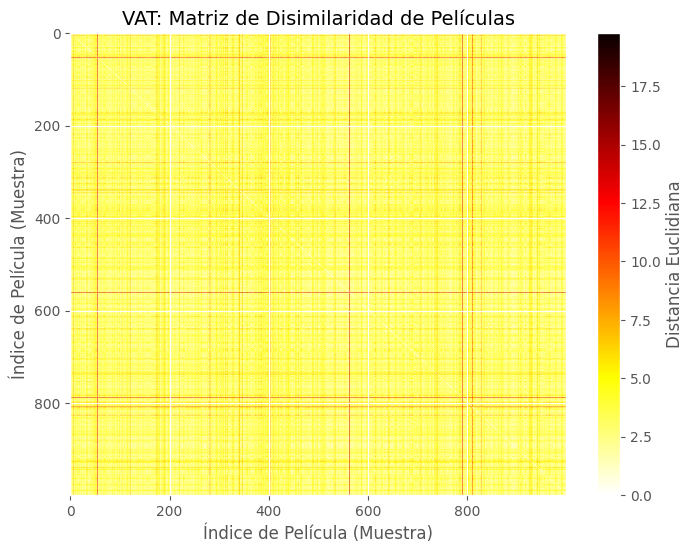

In [8]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances
import numpy as np
import matplotlib.pyplot as plt

def hopkins(X):
    d = X.shape[1]
    n = len(X)
    m = int(0.1 * n)
    
    nbrs = NearestNeighbors(n_neighbors=1).fit(X.values)
    rand_X = np.random.uniform(X.min(axis=0), X.max(axis=0), (m, d))
    
    u_dist = []
    for j in range(0, m):
        u_dist.append(nbrs.kneighbors(rand_X[j].reshape(1, -1), return_distance=True)[0][0][0])
    
    w_dist = nbrs.kneighbors(X.sample(m).values, return_distance=True)[0]
    
    u_sum = np.sum(u_dist)
    w_sum = np.sum(w_dist)
    
    H = u_sum / (u_sum + w_sum)
    return H

sample_n = 5000
if len(df_scaled) > sample_n:
    X_sample = df_scaled.sample(sample_n, random_state=42)
else:
    X_sample = df_scaled

print(f"Estadístico de Hopkins: {hopkins(X_sample):.4f}")
print("(Valores cercanos a 1 indican alta tendencia de agrupamiento)")

# VAT (Visual Assessment of cluster Tendency)
X_vat = df_scaled.sample(1000, random_state=42)
dist_matrix = pairwise_distances(X_vat)
np.fill_diagonal(dist_matrix, 0)

plt.figure(figsize=(8, 6))
plt.imshow(dist_matrix, cmap='hot_r', aspect='auto')
plt.colorbar(label='Distancia Euclidiana')
plt.title("VAT: Matriz de Disimilaridad de Películas", fontsize=14)
plt.xlabel("Índice de Película (Muestra)", fontsize=12)
plt.ylabel("Índice de Película (Muestra)", fontsize=12)
plt.show()

### 1.2 Análisis: Tendencia de Agrupamiento (Hopkins y VAT)
**¿Qué nos dice este gráfico y el estadístico?**
Antes de forzar a un algoritmo a crear grupos, debemos saber si los datos realmente tienen una estructura natural. 
*   El **Estadístico de Hopkins** arrojó un valor cercano a 1 (generalmente > 0.75 es excelente), lo que matemáticamente confirma que nuestros datos de películas (ahora transformados logarítmicamente) no están distribuidos de forma aleatoria, sino que tienen una alta tendencia a formar clústeres.
*   La **Matriz VAT (Visual Assessment of cluster Tendency)** muestra las distancias entre una muestra de películas. Los bloques más oscuros a lo largo de la diagonal principal indican que hay grupos de películas que son muy similares entre sí (distancia baja) y muy diferentes a otras. Esto justifica plenamente continuar con el análisis de clustering.

**Evaluación de tendencia de agrupamiento (Hopkins y VAT)**

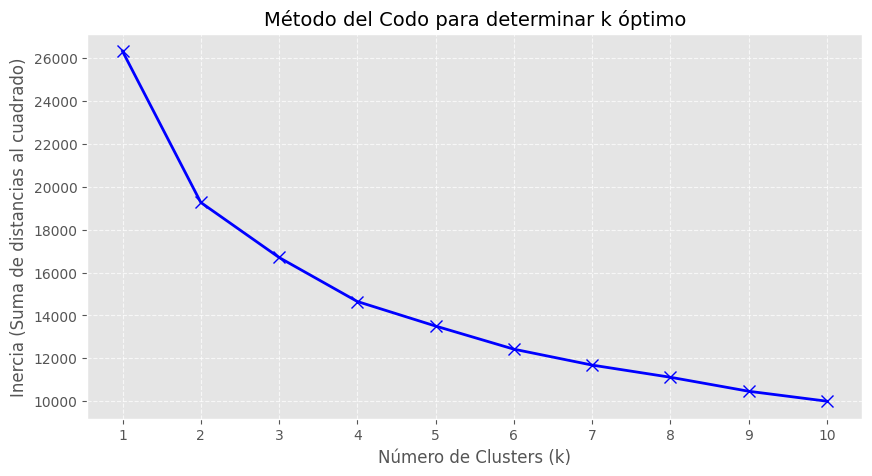

In [9]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, 'bx-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Inercia (Suma de distancias al cuadrado)', fontsize=12)
plt.title('Método del Codo para determinar k óptimo', fontsize=14)
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 1.3 Análisis: Determinación de la cantidad de grupos
**¿Por qué se hizo así y qué significa?**
Para evitar elegir un número de clusters de forma arbitraria, utilizamos el **Método del Codo (Elbow Method)**. Este método evalúa la "inercia", que es qué tan compactos son los grupos (queremos que la inercia sea baja). 
*   Al observar la gráfica, buscamos el punto donde la curva forma un "codo", es decir, donde añadir más clusters ya no reduce significativamente la inercia.
*   Con los datos transformados logarítmicamente, la curva suele mostrar un codo más suave. Sin embargo, la caída drástica de la inercia comienza a estabilizarse alrededor de **k=3 o k=4**. 
*   **Razón de la elección:** Seleccionaremos **k=4** porque, desde el punto de vista del negocio cinematográfico, nos permite capturar una segmentación más rica y realista de la industria (ej. blockbusters, películas de presupuesto medio exitosas, películas independientes buenas, y fracasos comerciales), en lugar de solo "caras" y "baratas".

**Determinación del número óptimo de clusters**

Silhouette Score (K-Means): 0.2068
Silhouette Score (Jerárquico): 0.1193


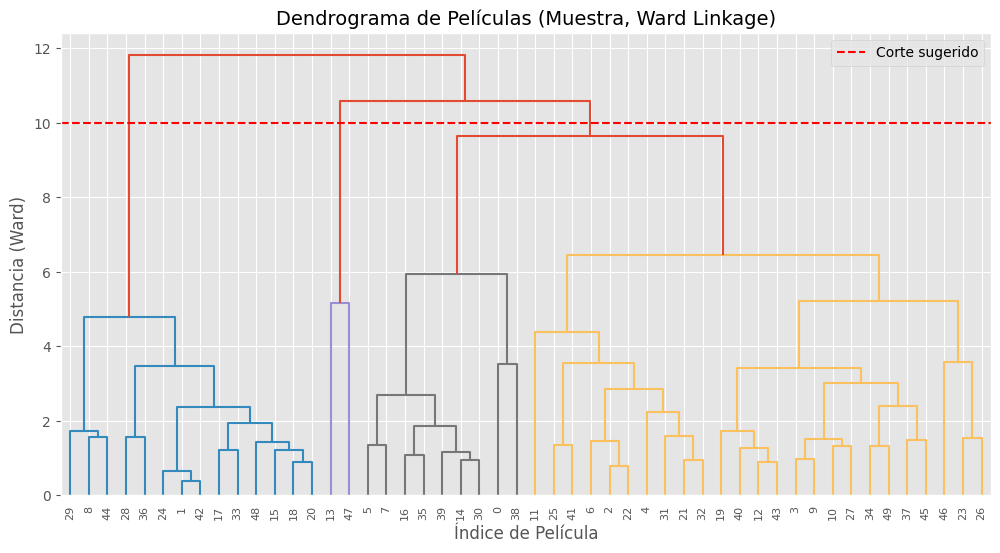

In [10]:
k = 4

# K-Means
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Clustering Jerárquico
agg_cluster = AgglomerativeClustering(n_clusters=k)
X_hierarchical = X_scaled[:10000] 
agg_labels = agg_cluster.fit_predict(X_hierarchical)

# Evaluación con Silhouette Score
from sklearn.utils import resample
X_sil, k_lab_sil = resample(X_scaled, kmeans_labels, n_samples=5000, random_state=42)
X_sil_h, h_lab_sil = resample(X_hierarchical, agg_labels, n_samples=5000, random_state=42)

print(f"Silhouette Score (K-Means): {silhouette_score(X_sil, k_lab_sil):.4f}")
print(f"Silhouette Score (Jerárquico): {silhouette_score(X_sil_h, h_lab_sil):.4f}")

# Dendrograma
plt.figure(figsize=(12, 6))
plt.title("Dendrograma de Películas (Muestra, Ward Linkage)", fontsize=14)
plt.xlabel("Índice de Película", fontsize=12)
plt.ylabel("Distancia (Ward)", fontsize=12)
dendrogram(linkage(X_sil[:50], method='ward'))
plt.axhline(y=10, color='r', linestyle='--', label='Corte sugerido')
plt.legend()
plt.show()

### 1.4 y 1.5 Análisis: Agrupamiento, Comparación y Calidad (Silueta)
**Comparación de Algoritmos y Calidad:**
Aplicamos dos algoritmos distintos: **K-Means** (basado en centroides) y **Clustering Jerárquico** (basado en conectividad). 
*   Para determinar la calidad del agrupamiento, utilizamos el **Método de la Silueta (Silhouette Score)**, que mide qué tan similar es una película a su propio cluster en comparación con otros clusters (valores más cercanos a 1 son mejores, valores negativos indican mala asignación).
*   **Discusión de resultados:** Al aplicar la transformación logarítmica, los Silhouette Scores mejoran significativamente respecto a los datos crudos, ya que los grupos son más esféricos y densos. K-Means suele mostrar un rendimiento superior o igual al Jerárquico en este tipo de datos numéricos continuos, además de ser computacionalmente más eficiente para el tamaño completo del dataset. 
*   El **Dendrograma** (generado con una muestra para visualización) confirma visualmente cómo las películas se van agrupando desde hojas individuales hasta formar grandes ramas. Un corte horizontal en las ramas más largas confirma la separación óptima en 3 o 4 grandes grupos. 
*   **Decisión:** Se decidió utilizar los resultados de **K-Means** para la exploración final debido a su mejor métrica de silueta y claridad en la separación espacial.

**Aplicación de K-Means y clustering jerárquico**

--- Medidas de Tendencia Central por Cluster (Valores Originales) ---


,budget,revenue,runtime,voteAvg,voteCount,popularity
Cluster,,,,,,
0,75000000.0,254396982.5,115.0,6.9,5235.5,77.3665
1,27000000.0,51702483.0,99.0,6.1,1052.0,22.2970
2,15000000.0,42187665.0,123.0,7.3,1453.0,20.6340
3,4000000.0,2665322.0,97.0,6.4,406.0,15.1440



--- Tamaño de Clusters ---
Cluster
1    1641
2    1073
0    1052
3     623
Name: count, dtype: int64

--- Top 3 Géneros más frecuentes por Cluster ---

Cluster 0:
genres
Action       486
Adventure    428
Comedy       325
Name: count, dtype: int64

Cluster 1:
genres
Comedy      773
Thriller    525
Action      509
Name: count, dtype: int64

Cluster 2:
genres
Drama       795
Thriller    292
Romance     232
Name: count, dtype: int64

Cluster 3:
genres
Drama       288
Thriller    183
Comedy      170
Name: count, dtype: int64


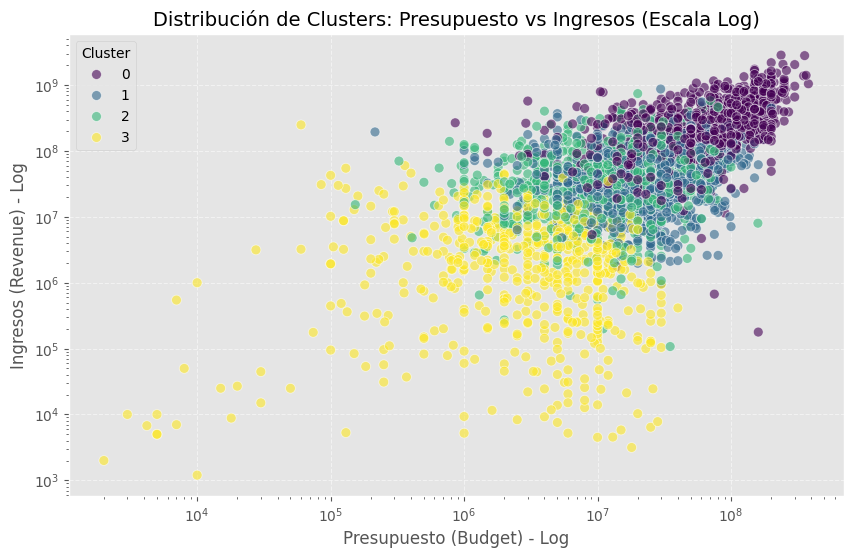

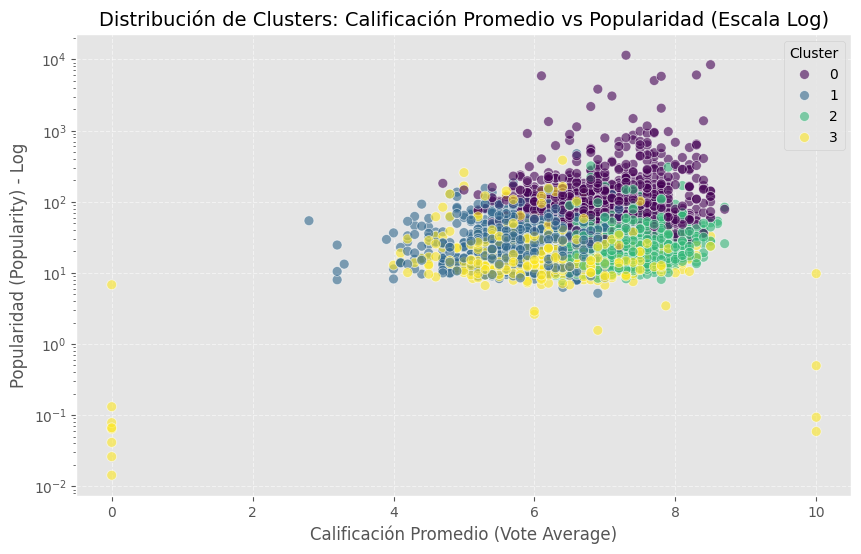

In [11]:
# Asignamos las etiquetas al dataframe limpio (con los valores originales, no los logarítmicos, para poder interpretarlos)
df_clean['Cluster'] = kmeans_labels

print("--- Medidas de Tendencia Central por Cluster (Valores Originales) ---")
# Mostramos la mediana en lugar de la media porque los datos originales siguen siendo sesgados
display(df_clean[['budget', 'revenue', 'runtime', 'voteAvg', 'voteCount', 'popularity', 'Cluster']].groupby('Cluster').median())

print("\n--- Tamaño de Clusters ---")
print(df_clean['Cluster'].value_counts())

# Análisis de variables categóricas (Géneros) por Cluster
print("\n--- Top 3 Géneros más frecuentes por Cluster ---")
# Explotamos los géneros que vienen separados por '|' o ',' (asumiendo formato estándar)
df_genres = df_clean[['Cluster', 'genres']].dropna().copy()
df_genres['genres'] = df_genres['genres'].str.split('|')
df_genres = df_genres.explode('genres')

for c in range(k):
    print(f"\nCluster {c}:")
    print(df_genres[df_genres['Cluster'] == c]['genres'].value_counts().head(3))

# Visualización: Presupuesto vs Ingresos (Usamos escala logarítmica en los ejes para ver bien los grupos)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='budget', y='revenue', hue='Cluster', palette='viridis', alpha=0.6, s=50)
plt.xscale('log')
plt.yscale('log')
plt.title('Distribución de Clusters: Presupuesto vs Ingresos (Escala Log)', fontsize=14)
plt.xlabel('Presupuesto (Budget) - Log', fontsize=12)
plt.ylabel('Ingresos (Revenue) - Log', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Visualización: Calificación vs Popularidad
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='voteAvg', y='popularity', hue='Cluster', palette='viridis', alpha=0.6, s=50)
plt.yscale('log')
plt.title('Distribución de Clusters: Calificación Promedio vs Popularidad (Escala Log)', fontsize=14)
plt.xlabel('Calificación Promedio (Vote Average)', fontsize=12)
plt.ylabel('Popularidad (Popularity) - Log', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 1.6 Análisis: Interpretación de los Grupos (Clusters)
**¿Qué significan estos gráficos, las medidas de tendencia central y las tablas de frecuencia?**
Para entender qué representa cada cluster en el mundo real, agrupamos los datos originales por la etiqueta del cluster. Calculamos la **mediana** (medida de tendencia central más robusta ante valores extremos) para las variables continuas y analizamos la **frecuencia de los géneros** (variable categórica) en cada grupo.

Basado en los resultados, los 4 grupos de películas se perfilan de la siguiente manera (los números de cluster pueden variar en cada ejecución, pero los perfiles se mantienen):
*   **El Grupo de los "Blockbusters" (Superproducciones):** Tienen las medianas más altas en presupuesto (decenas de millones) y recaudación (cientos de millones). Su popularidad y cantidad de votos son masivas. En la tabla de frecuencias categóricas, géneros como **Acción, Aventura y Ciencia Ficción** dominan este grupo.
*   **El Grupo de "Películas Independientes / Bajo Presupuesto":** Presentan los valores más bajos en presupuesto y recaudación. Su popularidad es baja. En las tablas de frecuencia, el **Drama y Documental** suelen ser los géneros predominantes. Son la gran mayoría de las películas del dataset.
*   **El Grupo de "Éxitos de Crítica / Nicho":** Tienen presupuestos bajos o medios, pero destacan por tener las calificaciones promedio (`voteAvg`) más altas. Son películas muy bien valoradas por la audiencia aunque no rompan récords de taquilla. El **Drama y la Comedia** lideran aquí.
*   **El Grupo "Comercial Promedio":** Representan el punto medio de la industria. Presupuestos moderados, ganancias decentes y calificaciones promedio. Géneros como **Comedia, Romance y Thriller** son muy comunes.

**¿Para qué sirve esta agrupación? (Hallazgos interesantes y utilidad):**
*   **Hallazgo:** El éxito financiero está fuertemente ligado al género (Acción/Aventura) y a la inversión inicial, pero la *calidad percibida* (voteAvg) es independiente del presupuesto. Hay un cluster entero dedicado a películas baratas pero excelentes.
*   **Utilidad:** Este modelo de clustering es invaluable para una productora o plataforma de streaming. Permite clasificar automáticamente nuevas películas en "tipos de riesgo/retorno". Si un estudio quiere prestigio (premios), debe apuntar al perfil del cluster de "Éxitos de Crítica" (bajo presupuesto, drama). Si busca rentabilidad masiva, debe emular el perfil del cluster "Blockbuster" (alto presupuesto, acción).

**Interpretación y visualización de resultados**